In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ukuran input yang sama seperti saat training
IMG_HEIGHT = 224
IMG_WIDTH  = 224

def show_image(img_bgr, title=None):
    """Tampilkan gambar BGR (OpenCV) dengan matplotlib."""
    if img_bgr is None:
        print("Image is None")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


In [2]:
# Cell 1: Load model TFLite yang sudah disimpan

import tensorflow as tf

# BASE_DIR = direktori kerja saat ini
BASE_DIR = os.getcwd()

MODEL_DIR = os.path.join(BASE_DIR, "Fraud_Detectio", "saved_models")
MODEL_PATH = os.path.join(MODEL_DIR, "ktp_fraud_cnn_tampering_v1.tflite")

print("BASE_DIR :", BASE_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("MODEL_PATH:", MODEL_PATH)

# Load TFLite model dengan Interpreter
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

# Dapatkan detail input dan output
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\nModel berhasil dimuat!")
print("Input shape:", input_details[0]['shape'])
print("Output shape:", output_details[0]['shape'])

BASE_DIR : d:\Coolyeah-Ngoding\PBL\Four-Heavenly-Principle\Machine Learning
MODEL_DIR: d:\Coolyeah-Ngoding\PBL\Four-Heavenly-Principle\Machine Learning\Fraud_Detectio\saved_models
MODEL_PATH: d:\Coolyeah-Ngoding\PBL\Four-Heavenly-Principle\Machine Learning\Fraud_Detectio\saved_models\ktp_fraud_cnn_tampering_v1.tflite

Model berhasil dimuat!
Input shape: [  1 224 224   3]
Output shape: [1 1]


c:\Users\rafir\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [3]:
def predict_external_ktp(interpreter, img_path, thresh_valid=0.5, show=True):
    """
    Prediksi 1 gambar KTP menggunakan TFLite Interpreter.

    Asumsi:
      - Output model sigmoid = P(VALID)
      - P(FRAUD) = 1 - P(VALID)

    Return:
      p_valid, p_fraud, label_str
    """
    img = cv2.imread(img_path)
    if img is None:
        print("Gagal membaca gambar:", img_path)
        return None, None, None
    
    # Resize sama seperti saat training
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    
    # Preprocess: BGR -> RGB, normalisasi ke [0, 1]
    x = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype("float32")
    x = x / 255.0  # Normalisasi
    x = np.expand_dims(x, axis=0)  # shape: (1, H, W, 3)

    # Set input tensor
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    interpreter.set_tensor(input_details[0]['index'], x)
    
    # Jalankan inferensi
    interpreter.invoke()
    
    # Ambil output
    output_data = interpreter.get_tensor(output_details[0]['index'])
    p_valid = float(output_data[0][0])
    p_fraud = 1.0 - p_valid

    # Aturan keputusan
    label = "VALID" if p_valid >= thresh_valid else "FRAUD"

    if show:
        title = (
            f"{os.path.basename(img_path)}\n"
            f"{label} | p_valid={p_valid:.3f}, p_fraud={p_fraud:.3f}, "
            f"thresh_valid={thresh_valid}"
        )
        show_image(img, title)

    return p_valid, p_fraud, label

In [4]:
# Cell 3: Prediksi semua KTP di satu folder

def predict_folder_ktp(interpreter, folder_path, thresh_valid=0.5, show_all_images=True):
    """
    Prediksi semua file .jpg/.jpeg/.png di dalam folder_path.

    Keputusan:
      - VALID jika p_valid >= thresh_valid
      - FRAUD jika p_valid <  thresh_valid
    """
    exts = (".jpg", ".jpeg", ".png")
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(exts)]
    files = sorted(files)

    print(f"Total file di folder {folder_path}: {len(files)}")
    print("=" * 60)

    results = []
    n_valid = 0
    n_fraud = 0

    for i, fname in enumerate(files, 1):
        path = os.path.join(folder_path, fname)
        p_valid, p_fraud, label = predict_external_ktp(
            interpreter, path, thresh_valid=thresh_valid, show=False
        )
        
        if p_valid is None:
            print(f"{i:2d}. {fname} -> GAGAL DIPROSES")
            continue
        
        results.append({
            "filename": fname,
            "p_valid": p_valid,
            "p_fraud": p_fraud,
            "label": label,
        })

        if label == "FRAUD":
            n_fraud += 1
            status_text = "MERAH (FRAUD)"
        else:
            n_valid += 1
            status_text = "HIJAU (VALID)"

        # Info per file
        print(f"{i:2d}. {fname}")
        print(f"     p_valid : {p_valid:.3f}")
        print(f"     p_fraud : {p_fraud:.3f}")
        print(f"     Status  : {status_text}")
        print("-" * 40)

        # Tampilkan gambar di notebook (opsional)
        if show_all_images:
            img = cv2.imread(path)
            if img is not None:
                img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
                title = (
                    f"{fname}\n"
                    f"{label} | p_valid={p_valid:.3f}, p_fraud={p_fraud:.3f}, "
                    f"thresh_valid={thresh_valid}"
                )
                show_image(img, title)
            else:
                print(f"     [PERINGATAN] Tidak dapat membaca gambar: {fname}")

    # Summary
    print("\n" + "=" * 60)
    print("SUMMARY HASIL PREDIKSI")
    print("=" * 60)
    print(f"Total File Diproses : {len(results)}")
    print(f"KTP VALID           : {n_valid} file")
    print(f"KTP FRAUD           : {n_fraud} file")
    if len(results) > 0:
        print(f"Persentase Fraud    : {n_fraud / len(results) * 100:.1f}%")
    else:
        print("Persentase Fraud    : 0.0%")
    print("=" * 60)
    
    return results

EXTERNAL_FOLDER: d:\Coolyeah-Ngoding\PBL\Four-Heavenly-Principle\Machine Learning\Fraud_Detectio\coba
Total file di folder d:\Coolyeah-Ngoding\PBL\Four-Heavenly-Principle\Machine Learning\Fraud_Detectio\coba: 4
 1. coba.jpeg
     p_valid : 0.044
     p_fraud : 0.956
     Status  : MERAH (FRAUD)
----------------------------------------


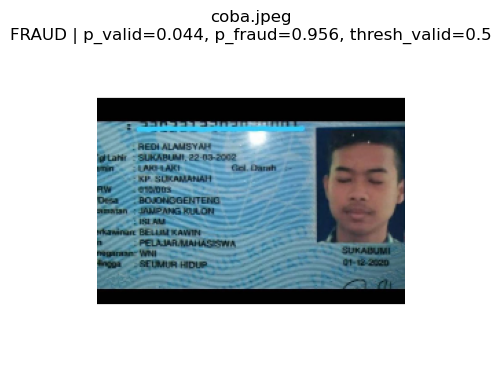

 2. images.jpg
     p_valid : 0.049
     p_fraud : 0.951
     Status  : MERAH (FRAUD)
----------------------------------------


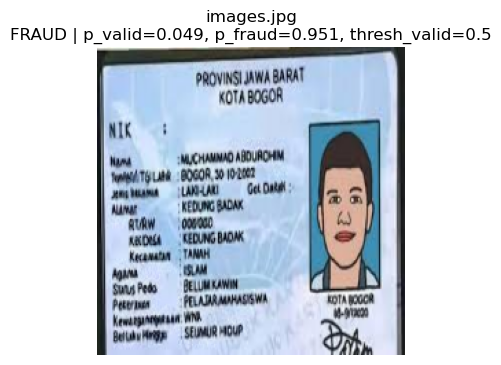

 3. ktpohim.jpeg
     p_valid : 0.048
     p_fraud : 0.952
     Status  : MERAH (FRAUD)
----------------------------------------


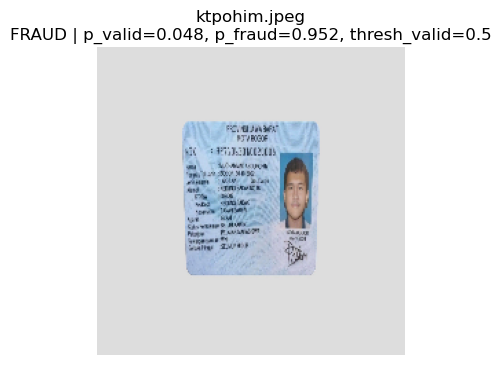

 4. pp.jpg
     p_valid : 0.048
     p_fraud : 0.952
     Status  : MERAH (FRAUD)
----------------------------------------


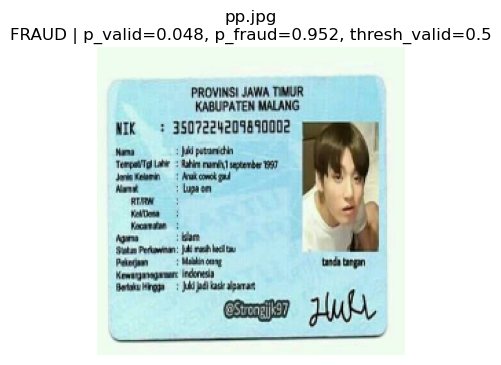


SUMMARY HASIL PREDIKSI
Total File Diproses : 4
KTP VALID           : 0 file
KTP FRAUD           : 4 file
Persentase Fraud    : 100.0%


In [5]:
# Cell 4: Jalankan prediksi di folder eksternal (mis: Fraud_Detectio/coba)

EXTERNAL_FOLDER = os.path.join(BASE_DIR, "Fraud_Detectio", "coba")

print("EXTERNAL_FOLDER:", EXTERNAL_FOLDER)

if os.path.isdir(EXTERNAL_FOLDER):
    res = predict_folder_ktp(
        interpreter,
        EXTERNAL_FOLDER,
        thresh_valid=0.5,
        show_all_images=True
    )
else:
    print(f"Folder tidak ditemukan: {EXTERNAL_FOLDER}")